[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muhammad-zainal-muttaqin/NulisBuku/blob/main/website/notebooks/ch05.ipynb)

Notebook Bab 5 ini punya dua bagian. Bagian **Demo** tinggal Anda jalankan lalu amati keluarannya; bagian **Mini Project** berisi soal dan data yang Anda kerjakan sendiri.

Penanganan nilai hilang dibuat reproducible dengan menaruh imputasi sebagai *transformer* di dalam *pipeline*, bukan suntingan manual. Saat fitur berkorelasi, imputasi berbasis model memanfaatkan kolom lain untuk menebak nilai yang hilang.


## Persiapan


In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
print('Setup selesai.')


from pathlib import Path
import json
import urllib.request
import urllib.parse

DATA_BASE_URL = 'https://raw.githubusercontent.com/muhammad-zainal-muttaqin/NulisBuku/main/website/notebooks/data/section1'


def section_data_dir(name):
    """Folder data Bagian 1: pakai salinan lokal bila ada; jika tidak (mis. di
    Google Colab), unduh berkas dari repo GitHub sesuai manifest."""
    for base in (Path('data/section1'), Path('../data/section1')):
        if (base / name).exists():
            return base / name
    cache = Path('_nb_data') / name
    if not (cache / 'manifest.json').exists():
        cache.mkdir(parents=True, exist_ok=True)
        base_url = DATA_BASE_URL + '/' + name
        manifest = json.loads(urllib.request.urlopen(base_url + '/manifest.json').read().decode('utf-8'))
        for rel in manifest:
            dest = cache / rel
            dest.parent.mkdir(parents=True, exist_ok=True)
            if not dest.exists():
                url = base_url + '/' + '/'.join(urllib.parse.quote(seg) for seg in rel.split('/'))
                urllib.request.urlretrieve(url, dest)
        (cache / 'manifest.json').write_text(json.dumps(manifest), encoding='utf-8')
    return cache


Setup selesai.


## Section 1 - Demo: Missingness Terstruktur dan Outlier pada Communities and Crime


## Data nyata: blok LEMAS/police yang hilang bersama


Snapshot: data\section1\ch05_communities_crime\communities.parquet
Baris: 1,994 | Kolom: 128 | Kolom dengan missing: 25
Rows dengan missing apa pun: 1,871
Kolom LEMAS/police dengan blok missing 1,675 baris: 22
Target ViolentCrimesPerPop: median=0.150, max=1.000, skew=1.523, IQR outliers=110

Kolom missing terbanyak:
PolicBudgPerPop         1675
LemasGangUnitDeploy     1675
LemasPctPolicOnPatr     1675
PolicCars               1675
PolicOperBudg           1675
PolicAveOTWorked        1675
LemasTotalReq           1675
LemasSwFTFieldPerPop    1675
PctPolicWhite           1675
RacialMatchCommPol      1675
LemasSwFTPerPop         1675
LemasSwFTFieldOps       1675


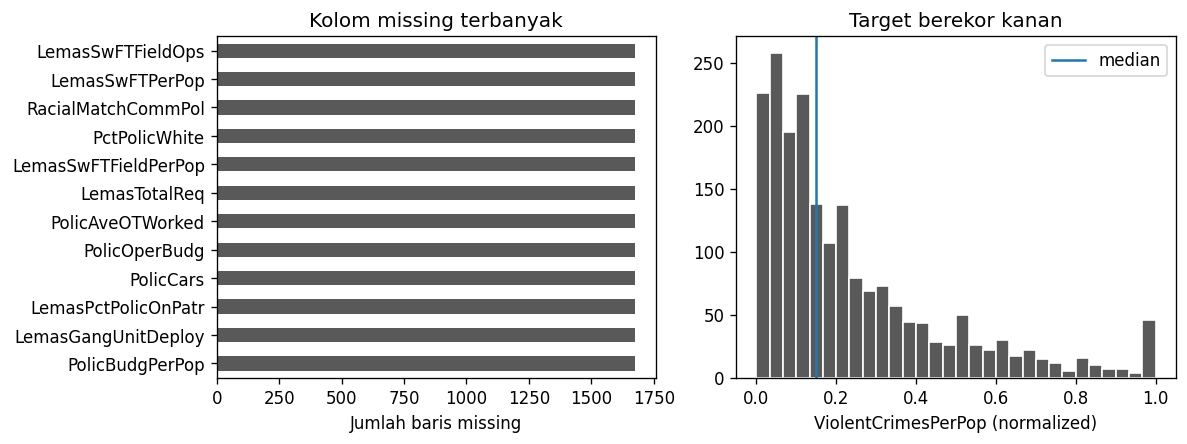

In [2]:
DATA_DIR = section_data_dir('ch05_communities_crime')
df = pd.read_parquet(DATA_DIR / 'communities.parquet')
stats = json.loads((DATA_DIR / 'verified_stats.json').read_text(encoding='utf-8'))

print('Snapshot:', DATA_DIR / 'communities.parquet')
print(f"Baris: {stats['rows']:,} | Kolom: {stats['column_count']} | Kolom dengan missing: {stats['missing_columns_count']}")
print(f"Rows dengan missing apa pun: {stats['rows_with_any_missing']:,}")
print(f"Kolom LEMAS/police dengan blok missing 1,675 baris: {stats['lemas_police_like_missing_columns_count']}")
print(f"Target ViolentCrimesPerPop: median={stats['target_median']:.3f}, max={stats['target_max']:.3f}, skew={stats['target_skew']:.3f}, IQR outliers={stats['target_iqr_outliers']}")

missing_table = pd.Series(stats['missing_columns']).sort_values(ascending=False).head(12)
print('\nKolom missing terbanyak:')
print(missing_table.to_string())

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
missing_table.sort_values().plot.barh(ax=axes[0], color='0.35')
axes[0].set_title('Kolom missing terbanyak')
axes[0].set_xlabel('Jumlah baris missing')
axes[1].hist(df['ViolentCrimesPerPop'], bins=30, color='0.35', edgecolor='white')
axes[1].axvline(df['ViolentCrimesPerPop'].median(), color='tab:blue', label='median')
axes[1].set_title('Target berekor kanan')
axes[1].set_xlabel('ViolentCrimesPerPop (normalized)')
axes[1].legend()
plt.tight_layout()


## Bandingkan imputasi, indikator missingness, dan clipping train-fold


In [3]:
class QuantileClipper(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lower_ = np.nanquantile(X, self.lower, axis=0)
        self.upper_ = np.nanquantile(X, self.upper, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float).copy()
        return np.clip(X, self.lower_, self.upper_)

lemas_cols = stats['lemas_police_like_missing_columns'][:10]
context_cols = [
    'population', 'householdsize', 'racepctblack', 'racePctWhite', 'racePctHisp',
    'agePct12t29', 'medIncome', 'PctPopUnderPov', 'PctUnemployed', 'PctKids2Par',
    'PctIlleg', 'PctImmigRecent', 'PctPersDenseHous', 'PctHousNoPhone', 'PopDens'
]
feature_cols = context_cols + lemas_cols
X = df[feature_cols]
y = df['ViolentCrimesPerPop']
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def rmse_score(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

scoring = {
    'rmse': make_scorer(rmse_score, greater_is_better=False),
    'r2': 'r2',
}

pipelines = {
    'median + StandardScaler': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0)),
    ]),
    'median+indicator + StandardScaler': Pipeline([
        ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0)),
    ]),
    'KNN imputer + StandardScaler': Pipeline([
        ('imputer', KNNImputer(n_neighbors=5)),
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0)),
    ]),
    'clipper + indicator + RobustScaler': Pipeline([
        ('clipper', QuantileClipper(lower=0.01, upper=0.99)),
        ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
        ('scaler', RobustScaler()),
        ('model', Ridge(alpha=1.0)),
    ]),
}

rows = []
for name, pipe in pipelines.items():
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring)
    rows.append({
        'pipeline': name,
        'RMSE_mean': -scores['test_rmse'].mean(),
        'RMSE_std': scores['test_rmse'].std(),
        'R2_mean': scores['test_r2'].mean(),
        'R2_std': scores['test_r2'].std(),
    })
print(pd.DataFrame(rows).round(4).to_string(index=False))
print('\nFitur demo:', len(feature_cols), 'kolom; termasuk', len(lemas_cols), 'kolom LEMAS/police dengan blok missing.')


                          pipeline  RMSE_mean  RMSE_std  R2_mean  R2_std
           median + StandardScaler     0.1411    0.0112   0.6304  0.0269
 median+indicator + StandardScaler     0.1404    0.0113   0.6339  0.0272
      KNN imputer + StandardScaler     0.1406    0.0119   0.6328  0.0282
clipper + indicator + RobustScaler     0.1399    0.0114   0.6363  0.0278

Fitur demo: 25 kolom; termasuk 10 kolom LEMAS/police dengan blok missing.


> 🔎 **Amati.** Missingness di sini bukan lubang acak kecil: banyak kolom LEMAS/police hilang bersama pada 1.675 komunitas, sehingga indikator missingness dapat membawa informasi tentang cakupan data. Semua strategi dipasang di dalam pipeline, jadi median, indikator, batas clipping, dan skala robust dipelajari ulang hanya dari fold pelatihan. Perbedaan skor sebaiknya dibaca sebagai efek representasi, bukan perlombaan memilih model terbaik.


## Section 2 - Mini Project

## Soal

Anda diberi data numerik yang mengandung nilai hilang dan *outlier*. Targetnya `nilai` (regresi).

Tugas:

1. Bangun *pipeline* reproducible: imputasi + penanganan *outlier* (`RobustScaler`) + model.
2. Tambahkan *missing-indicator* (`SimpleImputer(add_indicator=True)`) dan cek apakah menaikkan skor.
3. Laporkan R2 dengan *cross-validation*.

**Luaran:** kode *pipeline*, R2 CV dengan dan tanpa *missing-indicator*, plus 2-3 kalimat analisis.

**Kriteria penilaian:** (a) seluruh transformasi di dalam *pipeline*; (b) penanganan *outlier* eksplisit; (c) evaluasi memakai *cross-validation*.


In [4]:
# DATA AWAL (jangan diubah) - fitur berkorelasi dengan nilai hilang dan outlier.
m = 900
g1 = np.random.default_rng(11).normal(size=m)
g2 = np.random.default_rng(22).normal(size=m)
eps = np.random.default_rng(33)
Xp = np.column_stack([
    g1 + 0.15 * eps.normal(size=m),
    g1 + 0.15 * eps.normal(size=m),
    g2 + 0.15 * eps.normal(size=m),
    g2 + 0.15 * eps.normal(size=m),
    eps.normal(size=m),
])
yp = 2.5 * g1 - 1.5 * g2 + eps.normal(scale=0.6, size=m)
Xp[np.random.default_rng(44).random(Xp.shape) < 0.01] *= 8      # outlier
Xp[np.random.default_rng(55).random(Xp.shape) < 0.20] = np.nan  # nilai hilang
print('Data:', Xp.shape, '| nilai hilang:', int(np.isnan(Xp).sum()))


Data: (900, 5) | nilai hilang: 863


In [5]:
# Kerjakan di sini.
# Petunjuk: Pipeline([('imp', SimpleImputer(add_indicator=True)), ('sc', RobustScaler()), ('m', Ridge())]).
